# 05 — BERTopic for wondr

Topic modeling pipeline untuk wondr by BNI menggunakan BERTopic dengan IndoBERT embeddings.

**Pipeline overview:**
1. Load preprocessed data + generate (or load cached) IndoBERT embeddings
2. Sensitivity analysis 3×3 grid (UMAP n_neighbors × HDBSCAN min_cluster_size)
3. Pick winner via c_v coherence (filter by topic count 15-30)
4. Validate winner with c_npmi
5. Final BERTopic fit with winner params
6. Inspect topics, refine domain stopwords (Phase B)
7. Re-fit with extended stopwords
8. DTM (topics_over_time) — monthly granularity
9. Cosine similarity matrices per topic (semantic drift)

**Methodology reference:** `bertopic_session_handoff_v2.md`

## Section 0 — Setup

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

from utils.embedding import load_indobert_model, generate_embeddings

## Section 1 — Load data + Generate embeddings

**Heads up:** First run akan generate embeddings dari scratch (~20-30 menit untuk wondr di CPU). Subsequent runs akan load dari cache (`data/embeddings/wondr_embeddings.npy`) — instant.

### 1.1 Load preprocessed data

In [3]:
df_wondr = pd.read_csv('data/processed/wondr_bertopic.csv')

print(f"Shape: {df_wondr.shape}")
print(f"Columns: {df_wondr.columns.tolist()}")
df_wondr.head()

Shape: (8982, 6)
Columns: ['review_id', 'review_text_cleaned', 'relative_month', 'relative_week', 'date_wib', 'rating']


,review_id,review_text_cleaned,relative_month,relative_week,date_wib,rating
0,05c4afd9-2b73-462f-93ed-ad2f853647b5,kok tidak bisa di screenshot bagaimana caranya...,1,1,2024-07-05 16:24:39,2
1,e4786af6-59c9-4f34-897f-d20f8c5f412b,mau daftar susah disuruh telpon bni tapi tidak...,1,1,2024-07-05 16:28:04,1
2,cc78e674-330f-46f1-b279-27a9cbe2d823,tidak bisa buka rekening padahal no hp sudah s...,1,1,2024-07-05 21:14:52,1
3,2441c0dc-eda3-4f2c-8abe-f860c951af50,fitur paling basic untuk cetak statement bulan...,1,1,2024-07-05 22:04:41,1
4,0afc898b-3b64-426d-acaf-ae6b3c4bc967,sangat bagus sekali tapi tidak ada pitur setor...,1,1,2024-07-05 23:54:54,2


In [4]:
# Sanity check: no nulls in critical columns
critical_cols = ['review_text_cleaned', 'relative_month', 'relative_week']
print("Null counts:")
print(df_wondr[critical_cols].isnull().sum())

Null counts:
review_text_cleaned    0
relative_month         0
relative_week          0
dtype: int64


In [5]:
# Sanity check: relative_month coverage (should be 1-12)
print("Relative month distribution:")
print(df_wondr['relative_month'].value_counts().sort_index())

Relative month distribution:
relative_month
1      302
2      395
3      544
4      678
5     2568
6     1297
7      727
8      621
9      462
10     357
11     388
12     643
Name: count, dtype: int64


### 1.2 Extract texts as list

BERTopic expects a list of strings, not a pandas Series. We extract once here and reuse throughout the notebook.

In [6]:
docs_wondr = df_wondr['review_text_cleaned'].tolist()

print(f"Total docs: {len(docs_wondr)}")
print(f"Sample doc: {docs_wondr[0][:200]}")

Total docs: 8982
Sample doc: kok tidak bisa di screenshot bagaimana caranya kasih bukti ke penerima bagaimana sih ini aplikasi


### 1.3 Load IndoBERT model

Loaded once and reused for all embedding operations. First call may take a few seconds (loading from local HuggingFace cache).

In [7]:
model = load_indobert_model()
print(f"Model loaded: {type(model).__name__}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded: SentenceTransformer


### 1.4 Generate embeddings (or load from cache)

**First run:** generate from scratch, save to `data/embeddings/wondr_embeddings.npy` (~20-30 min on CPU).

**Subsequent runs:** load from cache (instant).

If preprocessing data changes, manually delete the cache file before re-running this cell.

In [8]:
embedding_cache_path = Path('data/embeddings/wondr_embeddings.npy')
embedding_cache_path.parent.mkdir(parents=True, exist_ok=True)

embeddings_wondr = generate_embeddings(
    texts=docs_wondr,
    model=model,
    cache_path=embedding_cache_path,
)

print(f"\nEmbedding shape: {embeddings_wondr.shape}")
print(f"Dtype: {embeddings_wondr.dtype}")
print(f"Cache file size: {embedding_cache_path.stat().st_size / (1024**2):.1f} MB")

[cache hit] Loading embeddings from data\embeddings\wondr_embeddings.npy
[cache hit] Shape: (8982, 768)

Embedding shape: (8982, 768)
Dtype: float32
Cache file size: 26.3 MB


## Section 2 — Sensitivity Analysis (3×3 Grid)

Run BERTopic with all 9 combinations of (n_neighbors, min_cluster_size) and record:
- Number of topics produced (excluding noise topic -1)
- c_v coherence score

Embedding is cached — only UMAP + HDBSCAN + c-TF-IDF re-run per combination. Estimated time: ~20-30 min total.

**Phase A stopwords:** Sastrawi only (~123 words). Domain-specific stopwords added in Phase B (Section 6-7).

In [11]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

from utils.clustering import build_umap_model, build_hdbscan_model
from utils.evaluation import compute_coherence
from utils.stopwords import get_sastrawi_stopwords

### 2.1 Setup grid + vectorizer config

The CountVectorizer config is shared across all 9 grid runs (only UMAP/HDBSCAN params vary).

In [14]:
# Grid search space
n_neighbors_grid = [10, 15, 25]
min_cluster_size_grid = [30, 60, 100]

# c-TF-IDF vectorizer (Phase A: Sastrawi stopwords only)
sastrawi_stopwords = get_sastrawi_stopwords()

vectorizer_model = CountVectorizer(
    stop_words=sastrawi_stopwords,
    ngram_range=(1, 2),
    min_df=2,        # was 10 — adjusted for topic-level doc count
    max_df=0.95,
)

print(f"Grid combinations: {len(n_neighbors_grid) * len(min_cluster_size_grid)}")
print(f"Sastrawi stopwords: {len(sastrawi_stopwords)} words")

Grid combinations: 9
Sastrawi stopwords: 123 words


### 2.2 Run grid search

For each combination: build UMAP + HDBSCAN, fit BERTopic with cached embeddings, compute c_v coherence, record results.

In [15]:
results = []

for nn in n_neighbors_grid:
    for mcs in min_cluster_size_grid:
        print(f"\n--- Fitting: n_neighbors={nn}, min_cluster_size={mcs} ---")
        
        umap_model = build_umap_model(n_neighbors=nn)
        hdbscan_model = build_hdbscan_model(min_cluster_size=mcs)
        
        topic_model = BERTopic(
            embedding_model=model,
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer_model,
            top_n_words=10,
            verbose=False,
        )
        
        topics, _ = topic_model.fit_transform(docs_wondr, embeddings=embeddings_wondr)
        
        n_topics = len(set(topics)) - (1 if -1 in topics else 0)
        c_v = compute_coherence(topic_model, docs_wondr, coherence='c_v')
        
        print(f"  -> n_topics: {n_topics}, c_v: {c_v:.4f}")
        
        results.append({
            'n_neighbors': nn,
            'min_cluster_size': mcs,
            'n_topics': n_topics,
            'c_v': c_v,
        })

results_df = pd.DataFrame(results)
print("\n=== Grid Search Results ===")
print(results_df.to_string(index=False))


--- Fitting: n_neighbors=10, min_cluster_size=30 ---
  -> n_topics: 35, c_v: 0.6637

--- Fitting: n_neighbors=10, min_cluster_size=60 ---
  -> n_topics: 5, c_v: 0.6320

--- Fitting: n_neighbors=10, min_cluster_size=100 ---
  -> n_topics: 8, c_v: 0.6801

--- Fitting: n_neighbors=15, min_cluster_size=30 ---
  -> n_topics: 27, c_v: 0.6755

--- Fitting: n_neighbors=15, min_cluster_size=60 ---
  -> n_topics: 15, c_v: 0.7055

--- Fitting: n_neighbors=15, min_cluster_size=100 ---
  -> n_topics: 8, c_v: 0.6876

--- Fitting: n_neighbors=25, min_cluster_size=30 ---
  -> n_topics: 24, c_v: 0.6520

--- Fitting: n_neighbors=25, min_cluster_size=60 ---
  -> n_topics: 14, c_v: 0.6982

--- Fitting: n_neighbors=25, min_cluster_size=100 ---
  -> n_topics: 8, c_v: 0.6866

=== Grid Search Results ===
 n_neighbors  min_cluster_size  n_topics      c_v
          10                30        35 0.663652
          10                60         5 0.632037
          10               100         8 0.680051
       

## Section 3 — Pick Winner via c_v

Filter grid results by topic count target (15-30), then select highest c_v.

**Result of grid search:**
- 3 combinations passed the topic count filter
- Winner: `n_neighbors=15, min_cluster_size=60` with c_v=0.7055 (15 topics)

In [16]:
# Apply topic count filter (15-30 topics target per methodology)
filtered = results_df[(results_df['n_topics'] >= 15) & (results_df['n_topics'] <= 30)]

print("Combinations passing filter (15 <= n_topics <= 30):")
print(filtered.to_string(index=False))

# Pick winner: highest c_v from filtered
winner = filtered.loc[filtered['c_v'].idxmax()]

print(f"\n=== WINNER ===")
print(f"n_neighbors:      {int(winner['n_neighbors'])}")
print(f"min_cluster_size: {int(winner['min_cluster_size'])}")
print(f"n_topics:         {int(winner['n_topics'])}")
print(f"c_v:              {winner['c_v']:.4f}")

# Store as variables for later use
best_n_neighbors = int(winner['n_neighbors'])
best_min_cluster_size = int(winner['min_cluster_size'])

Combinations passing filter (15 <= n_topics <= 30):
 n_neighbors  min_cluster_size  n_topics      c_v
          15                30        27 0.675528
          15                60        15 0.705541
          25                30        24 0.651993

=== WINNER ===
n_neighbors:      15
min_cluster_size: 60
n_topics:         15
c_v:              0.7055


## Section 4 — Validate Winner with c_npmi

Re-fit BERTopic with winner params, compute both c_v and c_npmi for comparison.

**Why this matters:** c_v is our primary metric for model selection (per Röder et al., 2015). c_npmi serves as secondary validation — if both metrics agree the winner is good, we have stronger confidence. If they disagree, we discuss it as an interesting finding (still prefer c_v winner).

**Heads up:** Re-fit takes ~30-60 seconds (single fit, not full grid).

In [17]:
from utils.evaluation import compute_coherence_both

# Re-fit with winner params
print(f"Re-fitting BERTopic with n_neighbors={best_n_neighbors}, "
      f"min_cluster_size={best_min_cluster_size}...")

umap_winner = build_umap_model(n_neighbors=best_n_neighbors)
hdbscan_winner = build_hdbscan_model(min_cluster_size=best_min_cluster_size)

topic_model_winner = BERTopic(
    embedding_model=model,
    umap_model=umap_winner,
    hdbscan_model=hdbscan_winner,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=False,
)

topics_winner, _ = topic_model_winner.fit_transform(
    docs_wondr, embeddings=embeddings_wondr
)

# Compute both coherence scores
scores = compute_coherence_both(topic_model_winner, docs_wondr)

n_topics_winner = len(set(topics_winner)) - (1 if -1 in topics_winner else 0)

print(f"\n=== Validation Results ===")
print(f"n_topics: {n_topics_winner}")
print(f"c_v:      {scores['c_v']:.4f}  (primary metric)")
print(f"c_npmi:   {scores['c_npmi']:.4f}  (validation metric)")

Re-fitting BERTopic with n_neighbors=15, min_cluster_size=60...

=== Validation Results ===
n_topics: 15
c_v:      0.7055  (primary metric)
c_npmi:   0.1723  (validation metric)


### Interpretation

| Metric | Score | Notes |
|---|---|---|
| c_v | 0.7055 | Primary metric, used for model selection |
| c_npmi | 0.1723 | Secondary validation metric |

**Verdict:** Both metrics agree the winner combination is coherent. c_v at 0.7055 indicates good topic quality (range 0.7+ is "good"), and c_npmi at 0.1723 confirms positive co-occurrence correlation among top-10 words per topic (range 0.15-0.25 is "good" for c_npmi). No disagreement between primary and secondary metrics — proceed to final fit and Phase B refinement.

Winner params:
- `n_neighbors`: 15 (UMAP)
- `min_cluster_size`: 60 (HDBSCAN)
- Yields 15 topics

## Section 5: Final Phase A Model

Berdasarkan grid search di Section 2 dan validasi metrik di Section 3-4, parameter winner adalah **`n_neighbors=15`** (UMAP) dan **`min_cluster_size=60`** (HDBSCAN), menghasilkan **15 topik** dengan c_v=0.7055 dan c_npmi=0.1723. Kedua metrik koherensi sepakat (no disagreement), sehingga model ini di-lock sebagai **Phase A final model**.

Model `topic_model_winner` yang sudah di-fit di Section 4 digunakan langsung sebagai Phase A final — tidak perlu re-fit karena UMAP menggunakan `random_state=42` (deterministic). Cell berikutnya men-dokumentasikan konfigurasi final untuk reproducibility.

In [18]:
# ============================================================
# PHASE A FINAL MODEL — Configuration Summary
# ============================================================
# This cell documents the locked configuration for Phase A.
# Model `topic_model_winner` is already fitted (from Section 4).
# No re-fit needed: UMAP uses random_state=42 (deterministic).
# ============================================================

phase_a_config = {
    "embedding_model": "indobenchmark/indobert-base-p2",
    "embedding_dim": 768,
    "umap": {
        "n_neighbors": best_n_neighbors,          # 15
        "n_components": 5,
        "min_dist": 0.0,
        "metric": "cosine",
        "random_state": 42,
    },
    "hdbscan": {
        "min_cluster_size": best_min_cluster_size,  # 60
        "metric": "euclidean",
        "cluster_selection_method": "eom",
        "prediction_data": True,
    },
    "vectorizer": {
        "stop_words": "sastrawi (123 words)",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95,
    },
    "results": {
        "n_topics": len(topic_model_winner.get_topic_info()) - 1,  # exclude outlier topic -1
        "c_v": 0.7055,
        "c_npmi": 0.1723,
    },
}

# Display nicely
import json
print("=" * 60)
print("PHASE A FINAL MODEL — LOCKED CONFIGURATION")
print("=" * 60)
print(json.dumps(phase_a_config, indent=2, default=str))
print("=" * 60)
print(f"\n✓ Model `topic_model_winner` ready for Section 6 (inspection)")

PHASE A FINAL MODEL — LOCKED CONFIGURATION
{
  "embedding_model": "indobenchmark/indobert-base-p2",
  "embedding_dim": 768,
  "umap": {
    "n_neighbors": 15,
    "n_components": 5,
    "min_dist": 0.0,
    "metric": "cosine",
    "random_state": 42
  },
  "hdbscan": {
    "min_cluster_size": 60,
    "metric": "euclidean",
    "cluster_selection_method": "eom",
    "prediction_data": true
  },
  "vectorizer": {
    "stop_words": "sastrawi (123 words)",
    "ngram_range": [
      1,
      2
    ],
    "min_df": 2,
    "max_df": 0.95
  },
  "results": {
    "n_topics": 15,
    "c_v": 0.7055,
    "c_npmi": 0.1723
  }
}

✓ Model `topic_model_winner` ready for Section 6 (inspection)


## Section 6: Topic Inspection (Phase A Output)

Phase A menggunakan stopword umum Bahasa Indonesia (Sastrawi). Untuk meningkatkan diskriminabilitas antar topik, dilakukan inspeksi manual terhadap output Phase A guna mengidentifikasi **domain-specific stopwords** — yaitu kata yang secara teknis informatif (misal "aplikasi", "bank") tetapi muncul terlalu sering di banyak topik sehingga tidak diskriminatif.

Hasil inspeksi akan ditambahkan ke `CUSTOM_DOMAIN_STOPWORDS` di `utils/stopwords.py`, lalu BERTopic di-fit ulang di Section 7 (Phase B).

In [19]:
# ============================================================
# Section 6.1 — Topic Overview
# ============================================================
topic_info = topic_model_winner.get_topic_info()
print(f"Total topics (incl. -1 outlier): {len(topic_info)}")
print(f"Real topics: {len(topic_info) - 1}")
print(f"Outlier docs (topic -1): {topic_info.loc[topic_info['Topic'] == -1, 'Count'].values[0]}")
print()
print(topic_info[['Topic', 'Count', 'Name']].to_string(index=False))

Total topics (incl. -1 outlier): 16
Real topics: 15
Outlier docs (topic -1): 5958

 Topic  Count                                       Name
    -1   5958            -1_pakai_transaksi_malah_mobile
     0    450  0_wajah_verifikasi wajah_verifikasi_gagal
     1    416        1_saldo_gagal_gagal saldo_transaksi
     2    399 2_gangguan_sering_gangguan terus_perbaikan
     3    365          3_mobile_lebih_bni mobile_banking
     4    264            4_tunai_tarik_tarik tunai_kartu
     5    171 5_mobile_bni mobile_banking_mobile banking
     6    163                  6_kode_email_kode otp_otp
     7    152             7_kendala_buka_perbaiki_dibuka
     8    118           8_pasword_salah_verifikasi_wajah
     9    106              9_buka_login_kok_aplikasi nya
    10    103                10_login_sesi_daftar_syarat
    11     90                  11_jangan_siap_kalau_dulu
    12     87                    12_buka_kok_dibuka_hari
    13     72        13_perbaiki_diperbaiki_sering_mohon
    1

In [20]:
# ============================================================
# Section 6.2 — Top-10 words per topic (compact view)
# ============================================================
print(f"{'Topic':<6} | {'Top 10 words (with c-TF-IDF scores)'}")
print("=" * 90)
for topic_id in range(len(topic_info) - 1):  # skip -1 outlier
    words_scores = topic_model_winner.get_topic(topic_id)
    words_str = ", ".join([f"{w}({s:.2f})" for w, s in words_scores])
    print(f"T{topic_id:<5} | {words_str}")

Topic  | Top 10 words (with c-TF-IDF scores)
T0     | wajah(0.15), verifikasi wajah(0.13), verifikasi(0.12), gagal(0.07), gagal terus(0.06), wajah gagal(0.04), wajah susah(0.03), susah banget(0.03), padahal(0.03), mengikuti(0.03)
T1     | saldo(0.11), gagal(0.06), gagal saldo(0.06), transaksi(0.05), transaksi gagal(0.04), berkurang(0.04), terpotong(0.04), pulsa(0.04), kepotong(0.03), transfer(0.03)
T2     | gangguan(0.11), sering(0.10), gangguan terus(0.05), perbaikan(0.05), sering error(0.05), banget(0.04), maintenance(0.04), sering gangguan(0.04), jelek(0.03), seharian(0.03)
T3     | mobile(0.04), lebih(0.03), bni mobile(0.03), banking(0.03), mobile banking(0.02), bank(0.02), transaksi(0.02), kalau(0.02), pakai(0.02), fitur(0.02)
T4     | tunai(0.21), tarik(0.19), tarik tunai(0.17), kartu(0.13), tunai kartu(0.11), fitur(0.08), setor(0.08), fitur tarik(0.07), setor tunai(0.06), atm(0.05)
T5     | mobile(0.13), bni mobile(0.10), banking(0.08), mobile banking(0.07), mending(0.07), lebih

In [21]:
# ============================================================
# Section 6.3 — Representative docs per topic
# ============================================================
# Untuk membantu interpretasi tema, lihat 3 dokumen paling representatif per topik

for topic_id in range(len(topic_info) - 1):
    print(f"\n{'='*90}")
    print(f"TOPIC {topic_id} (n={topic_info.loc[topic_info['Topic'] == topic_id, 'Count'].values[0]} docs)")
    
    # Top words
    top_words = [w for w, _ in topic_model_winner.get_topic(topic_id)[:10]]
    print(f"Top words: {', '.join(top_words)}")
    
    # Representative docs (3 paling representatif)
    rep_docs = topic_model_winner.get_representative_docs(topic_id)[:3]
    print(f"\nRepresentative docs:")
    for i, doc in enumerate(rep_docs, 1):
        # Truncate panjang doc biar gak bikin cell output overwhelming
        doc_preview = doc[:200] + "..." if len(doc) > 200 else doc
        print(f"  {i}. {doc_preview}")


TOPIC 0 (n=450 docs)
Top words: wajah, verifikasi wajah, verifikasi, gagal, gagal terus, wajah gagal, wajah susah, susah banget, padahal, mengikuti

Representative docs:
  1. untuk verifikasi wajah susah banget
  2. susah banget verifikasi wajah gagal terus
  3. susah verifikasi wajah gagal terus

TOPIC 1 (n=416 docs)
Top words: saldo, gagal, gagal saldo, transaksi, transaksi gagal, berkurang, terpotong, pulsa, kepotong, transfer

Representative docs:
  1. transaksi gagal tapi saldo berkurang saat pembelian token listrik
  2. beli pulsa lewat aplikasi saldo berkurang transaksi gagal saldo tidak kembali bagaimana ini
  3. transaksi gagal tapi saldo terpotong

TOPIC 2 (n=399 docs)
Top words: gangguan, sering, gangguan terus, perbaikan, sering error, banget, maintenance, sering gangguan, jelek, seharian

Representative docs:
  1. aplikasi sering gangguan tidak jelas
  2. jelek banget aplikasi sering gangguan dan lemot
  3. sering gangguan atau bisa juga sering perbaikan sistem

TOPIC 3 (

In [24]:
from utils.stopwords import CUSTOM_DOMAIN_STOPWORDS

In [25]:
# ============================================================
# Section 7.1 — Verify extended stopwords
# ============================================================
from utils.stopwords import get_sastrawi_stopwords, get_extended_stopwords

sastrawi_only = get_sastrawi_stopwords()
extended = get_extended_stopwords()

print(f"Sastrawi only:        {len(sastrawi_only)} words")
print(f"Extended (Phase B):   {len(extended)} words")
print(f"Custom added:         {len(extended) - len(sastrawi_only)} words")
print()
print(f"Custom domain words added (not in Sastrawi):")
custom_only = sorted(set(extended) - set(sastrawi_only))
print(f"  {custom_only}")

Sastrawi only:        123 words
Extended (Phase B):   135 words
Custom added:         12 words

Custom domain words added (not in Sastrawi):
  ['aplikasi', 'banget', 'bni', 'deh', 'dulu', 'kalau', 'kalo', 'kok', 'mending', 'nya', 'sih', 'wondr']


In [26]:
# ============================================================
# Section 7.2 — Re-instantiate vectorizer with Phase B stopwords
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer

extended_stopwords = get_extended_stopwords()

vectorizer_model_phase_b = CountVectorizer(
    stop_words=extended_stopwords,
    ngram_range=(1, 2),
    min_df=2,        # same as Phase A (BERTopic topic-level c-TF-IDF)
    max_df=0.95,
)

print(f"Phase B vectorizer instantiated.")
print(f"  Stopwords: {len(extended_stopwords)} words (Sastrawi {len(get_sastrawi_stopwords())} + custom {len(CUSTOM_DOMAIN_STOPWORDS)})")
print(f"  ngram_range: (1, 2)")
print(f"  min_df: 2, max_df: 0.95")

Phase B vectorizer instantiated.
  Stopwords: 135 words (Sastrawi 123 + custom 13)
  ngram_range: (1, 2)
  min_df: 2, max_df: 0.95


In [27]:
# ============================================================
# Section 7.3 — Re-fit BERTopic with Phase B vectorizer
# ============================================================
from bertopic import BERTopic
import time

# Re-build UMAP and HDBSCAN with same winner params
# (we need fresh instances since UMAP/HDBSCAN keep internal state after fit)
umap_phase_b = build_umap_model(n_neighbors=best_n_neighbors)
hdbscan_phase_b = build_hdbscan_model(min_cluster_size=best_min_cluster_size)

topic_model_phase_b = BERTopic(
    embedding_model=model,
    umap_model=umap_phase_b,
    hdbscan_model=hdbscan_phase_b,
    vectorizer_model=vectorizer_model_phase_b,   # ← NEW: extended stopwords
    top_n_words=10,
    verbose=True,
)

t0 = time.time()
topics_phase_b, probs_phase_b = topic_model_phase_b.fit_transform(
    docs_wondr, embeddings=embeddings_wondr
)
elapsed = time.time() - t0

print(f"\n✓ Phase B fit complete in {elapsed:.1f}s")
print(f"  Total topics (incl. -1): {len(topic_model_phase_b.get_topic_info())}")
print(f"  Real topics: {len(topic_model_phase_b.get_topic_info()) - 1}")
print(f"  Outlier docs (topic -1): {topic_model_phase_b.get_topic_info().loc[topic_model_phase_b.get_topic_info()['Topic'] == -1, 'Count'].values[0]}")

2026-05-07 03:27:17,591 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-07 03:27:44,346 - BERTopic - Dimensionality - Completed ✓
2026-05-07 03:27:44,352 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 03:27:45,314 - BERTopic - Cluster - Completed ✓
2026-05-07 03:27:45,328 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 03:27:45,983 - BERTopic - Representation - Completed ✓



✓ Phase B fit complete in 28.7s
  Total topics (incl. -1): 16
  Real topics: 15
  Outlier docs (topic -1): 5958


In [29]:
# ============================================================
# Section 7.4 — Coherence comparison: Phase A vs Phase B
# ============================================================
from utils.evaluation import compute_coherence_both

# Compute Phase B coherence (both c_v and c_npmi in one pass)
print("Computing Phase B coherence (c_v + c_npmi)...")
scores_phase_b = compute_coherence_both(topic_model_phase_b, docs_wondr)

cv_phase_b = scores_phase_b["c_v"]
npmi_phase_b = scores_phase_b["c_npmi"]

# Phase A values from M2 (already known, no need to recompute)
cv_phase_a = 0.7055
npmi_phase_a = 0.1723

# Comparison table
print("\n" + "=" * 60)
print("COHERENCE COMPARISON: PHASE A vs PHASE B")
print("=" * 60)
print(f"{'Metric':<10} | {'Phase A':>10} | {'Phase B':>10} | {'Δ':>10} | {'Direction':<10}")
print("-" * 60)

delta_cv = cv_phase_b - cv_phase_a
delta_npmi = npmi_phase_b - npmi_phase_a

direction_cv = "↑ better" if delta_cv > 0 else ("↓ worse" if delta_cv < 0 else "= same")
direction_npmi = "↑ better" if delta_npmi > 0 else ("↓ worse" if delta_npmi < 0 else "= same")

print(f"{'c_v':<10} | {cv_phase_a:>10.4f} | {cv_phase_b:>10.4f} | {delta_cv:>+10.4f} | {direction_cv}")
print(f"{'c_npmi':<10} | {npmi_phase_a:>10.4f} | {npmi_phase_b:>10.4f} | {delta_npmi:>+10.4f} | {direction_npmi}")
print("=" * 60)

Computing Phase B coherence (c_v + c_npmi)...

COHERENCE COMPARISON: PHASE A vs PHASE B
Metric     |    Phase A |    Phase B |          Δ | Direction 
------------------------------------------------------------
c_v        |     0.7055 |     0.6754 |    -0.0301 | ↓ worse
c_npmi     |     0.1723 |     0.1613 |    -0.0110 | ↓ worse


In [30]:
# ============================================================
# Section 7.5 — Side-by-side top words: Phase A vs Phase B
# ============================================================
print(f"{'T#':<3} | {'Phase A top-10 words':<55} | {'Phase B top-10 words':<55}")
print("=" * 120)

for topic_id in range(15):  # 15 real topics
    # Phase A top words
    words_a = [w for w, _ in topic_model_winner.get_topic(topic_id)]
    str_a = ", ".join(words_a)

    # Phase B top words
    words_b = [w for w, _ in topic_model_phase_b.get_topic(topic_id)]
    str_b = ", ".join(words_b)

    # Truncate kalau kepanjangan biar fit di terminal
    str_a = (str_a[:52] + "...") if len(str_a) > 55 else str_a
    str_b = (str_b[:52] + "...") if len(str_b) > 55 else str_b

    print(f"T{topic_id:<2} | {str_a:<55} | {str_b:<55}")

T#  | Phase A top-10 words                                    | Phase B top-10 words                                   
T0  | wajah, verifikasi wajah, verifikasi, gagal, gagal te... | wajah, verifikasi wajah, verifikasi, gagal, gagal te...
T1  | saldo, gagal, gagal saldo, transaksi, transaksi gaga... | saldo, gagal saldo, gagal, transaksi, transaksi gaga...
T2  | gangguan, sering, gangguan terus, perbaikan, sering ... | gangguan, sering, gangguan terus, sering error, perb...
T3  | mobile, lebih, bni mobile, banking, mobile banking, ... | mobile, lebih, banking, mobile banking, bank, transa...
T4  | tunai, tarik, tarik tunai, kartu, tunai kartu, fitur... | tunai, tarik, tarik tunai, kartu, tunai kartu, fitur...
T5  | mobile, bni mobile, banking, mobile banking, mending... | mobile, banking, mobile banking, lebih, pakai mobile...
T6  | kode, email, kode otp, otp, kode kode, verifikasi em... | kode, email, otp, kode otp, kode kode, verifikasi em...
T7  | kendala, buka, perbaiki, dibuka, c

In [31]:
# ============================================================
# Section 7.6 — Representative docs Phase B (key topics)
# ============================================================
# Inspect 5 topics yang berubah signifikan atau borderline:
# - T3, T5: redundancy check (BNI Mobile Banking comparison)
# - T9: shift dari "gagal buka generic" → "login error after update"?
# - T11: shift dari "rant pattern" → "premature launch complaint"?
# - T12: shift dari "kok gak bisa buka" → "intermittent unavailability"?

key_topics = [3, 5, 9, 11, 12]

for topic_id in key_topics:
    print(f"\n{'='*90}")
    n_docs = topic_model_phase_b.get_topic_info().loc[
        topic_model_phase_b.get_topic_info()['Topic'] == topic_id, 'Count'
    ].values[0]
    print(f"TOPIC {topic_id} (n={n_docs} docs) — Phase B")
    
    # Top words Phase B
    top_words = [w for w, _ in topic_model_phase_b.get_topic(topic_id)[:10]]
    print(f"Top words: {', '.join(top_words)}")
    
    # Representative docs (3 paling representatif)
    rep_docs = topic_model_phase_b.get_representative_docs(topic_id)[:3]
    print(f"\nRepresentative docs:")
    for i, doc in enumerate(rep_docs, 1):
        doc_preview = doc[:250] + "..." if len(doc) > 250 else doc
        print(f"  {i}. {doc_preview}")


TOPIC 3 (n=365 docs) — Phase B
Top words: mobile, lebih, banking, mobile banking, bank, transaksi, pakai, fitur, nasabah, rekening

Representative docs:
  1. bagaimana dengan bni mobile banking apakah wondr ini lebih baik dari bni mobile banking apakah bni mobile banking nya di uninstall saja biar tidak ribet
  2. tidak lebih bagus dari mobile banking bni yang lama saya termasuk nasabah yang nyaman melihat model tampilan transaksi yang terlihat saldo akhirnya transaksi jenis transaksi saldo akhir ini maksudnya tampilan wondr tidak jauh beda dari livin by mandi...
  3. bni salah langkah dengan mengabaikan kepuasan pengguna mobile banking fitur di mobile banking di kurangi dan di persulit untuk transaksi user itu ingin di satu aplikasi bisa semua bukan di arahkan di aplikasi yang lain lagi ini beli token listrik saj...

TOPIC 5 (n=171 docs) — Phase B
Top words: mobile, banking, mobile banking, lebih, pakai mobile, pakai, ribet, sering, jelek, bagus

Representative docs:
  1. lebih bagus

In [32]:
# ============================================================
# Section 7.7 — Manual merge: Phase C (final model)
# ============================================================
# Based on Section 7.6 representative docs inspection:
# - T3 + T5: both about "BNI Mobile Banking comparison/preference"
#   (distinction is verbosity, not theme)
# - T9 + T12: both about "aplikasi gak bisa dibuka"
#   (rep docs nearly identical despite different top words)
#
# Note: BERTopic merge_topics modifies the model IN-PLACE.
# We work on a COPY to preserve topic_model_phase_b for comparison.

import copy

# Deep copy Phase B model to create Phase C
topic_model_phase_c = copy.deepcopy(topic_model_phase_b)

# Define merge groups (each inner list = topics to merge into one)
topics_to_merge = [
    [3, 5],   # BNI Mobile Banking redundancy
    [9, 12],  # "Gagal buka aplikasi" redundancy
]

# Apply merge — BERTopic re-assigns topic IDs after merge
topic_model_phase_c.merge_topics(docs_wondr, topics_to_merge)

# Verify result
phase_c_info = topic_model_phase_c.get_topic_info()
print(f"Phase C topic count:")
print(f"  Total topics (incl. -1): {len(phase_c_info)}")
print(f"  Real topics: {len(phase_c_info) - 1}")
print()
print(phase_c_info[['Topic', 'Count', 'Name']].to_string(index=False))

Phase C topic count:
  Total topics (incl. -1): 14
  Real topics: 13

 Topic  Count                                            Name
    -1   5958                 -1_pakai_transaksi_mobile_login
     0    536              0_mobile_lebih_mobile banking_bank
     1    450 1_wajah_verifikasi wajah_verifikasi_gagal terus
     2    416   2_saldo_gagal saldo_transaksi_transaksi gagal
     3    399   3_gangguan_sering_gangguan terus_sering error
     4    264                 4_tunai_tarik_tarik tunai_kartu
     5    193                 5_buka_login_dibuka_terus login
     6    163                       6_kode_email_kode otp_otp
     7    152                  7_kendala_buka_perbaiki_dibuka
     8    118                8_pasword_salah_verifikasi_wajah
     9    103                      9_login_sesi_daftar_syarat
    10     90                 10_jangan_siap_siap jangan_usah
    11     72             11_perbaiki_diperbaiki_sering_mohon
    12     68                        12_juta_wallet_up_top up


In [33]:
# ============================================================
# Section 7.8 — Coherence comparison: Phase A vs B vs C
# ============================================================
print("Computing Phase C coherence...")
scores_phase_c = compute_coherence_both(topic_model_phase_c, docs_wondr)

cv_phase_c = scores_phase_c["c_v"]
npmi_phase_c = scores_phase_c["c_npmi"]

# 3-way comparison
print("\n" + "=" * 70)
print("COHERENCE COMPARISON: PHASE A vs B vs C")
print("=" * 70)
print(f"{'Metric':<10} | {'Phase A':>10} | {'Phase B':>10} | {'Phase C':>10} | {'B→C Δ':>10}")
print("-" * 70)
print(f"{'c_v':<10} | {cv_phase_a:>10.4f} | {cv_phase_b:>10.4f} | {cv_phase_c:>10.4f} | {cv_phase_c - cv_phase_b:>+10.4f}")
print(f"{'c_npmi':<10} | {npmi_phase_a:>10.4f} | {npmi_phase_b:>10.4f} | {npmi_phase_c:>10.4f} | {npmi_phase_c - npmi_phase_b:>+10.4f}")
print("-" * 70)
print(f"{'n_topics':<10} | {15:>10} | {15:>10} | {13:>10}")
print("=" * 70)

Computing Phase C coherence...

COHERENCE COMPARISON: PHASE A vs B vs C
Metric     |    Phase A |    Phase B |    Phase C |      B→C Δ
----------------------------------------------------------------------
c_v        |     0.7055 |     0.6754 |     0.6964 |    +0.0210
c_npmi     |     0.1723 |     0.1613 |     0.1752 |    +0.0139
----------------------------------------------------------------------
n_topics   |         15 |         15 |         13


In [34]:
# ============================================================
# Section 7.9 — Final Phase C topic overview
# ============================================================
print(f"{'T#':<3} | {'n':<5} | {'Top 10 words'}")
print("=" * 100)
for topic_id in range(13):  # 13 real topics
    n_docs = topic_model_phase_c.get_topic_info().loc[
        topic_model_phase_c.get_topic_info()['Topic'] == topic_id, 'Count'
    ].values[0]
    top_words = [w for w, _ in topic_model_phase_c.get_topic(topic_id)]
    print(f"T{topic_id:<2} | {n_docs:<5} | {', '.join(top_words)}")

T#  | n     | Top 10 words
T0  | 536   | mobile, lebih, mobile banking, bank, pakai, transaksi, bagus, fitur, nasabah, banyak
T1  | 450   | wajah, verifikasi wajah, verifikasi, gagal terus, wajah gagal, wajah susah, mengikuti, verivikasi, kali, tetap
T2  | 416   | saldo, gagal saldo, transaksi, transaksi gagal, berkurang, terpotong, pulsa, kepotong, saldo berkurang, transfer
T3  | 399   | gangguan, sering, gangguan terus, sering error, perbaikan, sering gangguan, maintenance, seharian, perbaikan terus, jam
T4  | 264   | tunai, tarik, tarik tunai, kartu, tunai kartu, fitur, setor, fitur tarik, setor tunai, atm
T5  | 193   | buka, login, dibuka, terus login, sekarang, buka buka, pagi, digunakan, buka sama, update
T6  | 163   | kode, email, kode otp, otp, kode kode, verifikasi email, verifikasi, kirim, kode verifikasi, otp email
T7  | 152   | kendala, buka, perbaiki, dibuka, coba, sedang, sedikit kendala, tetap, sedikit, tim
T8  | 118   | pasword, salah, verifikasi, wajah, pin, password, 

In [35]:
# ============================================================
# Section 7.10 — Persist Phase C model for Section 8 (DTM)
# ============================================================
import os
os.makedirs("data/models", exist_ok=True)

topic_model_phase_c.save(
    "data/models/wondr_phase_c",
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model=False,  # IndoBERT loaded separately, saves ~400MB
)

print("✓ Phase C model saved to data/models/wondr_phase_c/")
print("  To reload in next session:")
print('    topic_model_phase_c = BERTopic.load("data/models/wondr_phase_c", embedding_model=model)')

2026-05-07 03:43:10,555 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


✓ Phase C model saved to data/models/wondr_phase_c/
  To reload in next session:
    topic_model_phase_c = BERTopic.load("data/models/wondr_phase_c", embedding_model=model)


In [9]:
# === Resume from handoff v4: reload Phase C model ===
from bertopic import BERTopic

topic_model_phase_c = BERTopic.load(
    "data/models/wondr_phase_c",
    embedding_model=model  # IndoBERT yang sudah di-load di Section 1
)

print(f"Phase C model loaded successfully")
print(f"Number of topics: {len(topic_model_phase_c.get_topic_info()) - 1}")  # -1 karena outlier (-1)
print(f"Total docs: {topic_model_phase_c.get_topic_info()['Count'].sum()}")

Phase C model loaded successfully
Number of topics: 13
Total docs: 8982


In [10]:
# === Pre-flight check: distribusi review per relative_month ===
month_dist = df_wondr['relative_month'].value_counts().sort_index()
print("Distribusi review per relative_month:")
print(month_dist)
print(f"\nTotal: {month_dist.sum()}")
print(f"Min: {month_dist.min()} | Max: {month_dist.max()}")
print(f"Ratio max/min: {month_dist.max()/month_dist.min():.2f}x")

Distribusi review per relative_month:
relative_month
1      302
2      395
3      544
4      678
5     2568
6     1297
7      727
8      621
9      462
10     357
11     388
12     643
Name: count, dtype: int64

Total: 8982
Min: 302 | Max: 2568
Ratio max/min: 8.50x


In [11]:
# === Section 8.1: Generate topics_over_time ===
import time

print("Running topics_over_time... (estimated 3-5 minutes)")
start = time.time()

timestamps = df_wondr['relative_month'].tolist()

topics_over_time = topic_model_phase_c.topics_over_time(
    docs=docs_wondr,
    timestamps=timestamps,
    nr_bins=12,
    evolution_tuning=True,
    global_tuning=True,
)

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Output shape: {topics_over_time.shape}")
print(f"Columns: {topics_over_time.columns.tolist()}")
print(f"\nSample (first 5 rows):")
print(topics_over_time.head())

Running topics_over_time... (estimated 3-5 minutes)


12it [00:01,  9.49it/s]


Done in 1.5s (0.0 min)
Output shape: (166, 4)
Columns: ['Topic', 'Words', 'Frequency', 'Timestamp']

Sample (first 5 rows):
   Topic                                              Words  Frequency  \
0     -1          verifikasi, ktp, mobile, transaksi, pakai        206   
1      0          mobile, lebih, fitur, mobile banking, kan         16   
2      1  wajah, verifikasi wajah, verifikasi, wajah gag...         29   
3      2       saldo, tanya, gagal saldo, pengembalian, isi         12   
4      3  becus kerjanya, proses daftar, daftar banyak, ...          3   

   Timestamp  
0      0.989  
1      0.989  
2      0.989  
3      0.989  
4      0.989  


In [12]:
# === Section 8.1 RETRY: Fix timestamp type ===
import time

print("Re-running topics_over_time with string timestamps...")
start = time.time()

# Convert relative_month ke string supaya BERTopic treat as categorical bucket
# Format "M01", "M02", ... "M12" supaya sort order tetap benar (M10 setelah M09, bukan setelah M01)
timestamps = df_wondr['relative_month'].apply(lambda x: f"M{x:02d}").tolist()

# Sanity check sebelum panggil DTM
print(f"Sample timestamps: {timestamps[:5]}")
print(f"Unique timestamps: {sorted(set(timestamps))}")
print(f"Length match: {len(timestamps) == len(docs_wondr)}")
print()

topics_over_time = topic_model_phase_c.topics_over_time(
    docs=docs_wondr,
    timestamps=timestamps,
    nr_bins=12,           # 12 bins for 12 unique months — 1:1 mapping
    evolution_tuning=True,
    global_tuning=True,
)

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Output shape: {topics_over_time.shape}")
print(f"Columns: {topics_over_time.columns.tolist()}")
print(f"\nUnique Timestamps in output:")
print(sorted(topics_over_time['Timestamp'].unique()))
print(f"\nSample (first 5 rows):")
print(topics_over_time.head())

Re-running topics_over_time with string timestamps...
Sample timestamps: ['M01', 'M01', 'M01', 'M01', 'M01']
Unique timestamps: ['M01', 'M02', 'M03', 'M04', 'M05', 'M06', 'M07', 'M08', 'M09', 'M10', 'M11', 'M12']
Length match: True



TypeError: to_datetime() got an unexpected keyword argument 'infer_datetime_format'

In [13]:
# === Section 8.1 RETRY v2: Pass integer timestamps WITHOUT nr_bins ===
import time

print("Re-running topics_over_time with integer timestamps, no binning...")
start = time.time()

# Integer timestamps (1, 2, 3, ..., 12) — BERTopic akan group exact by unique value
timestamps = df_wondr['relative_month'].tolist()

# Sanity check
print(f"Sample timestamps: {timestamps[:5]}")
print(f"Unique timestamps: {sorted(set(timestamps))}")
print(f"Length match: {len(timestamps) == len(docs_wondr)}")
print()

topics_over_time = topic_model_phase_c.topics_over_time(
    docs=docs_wondr,
    timestamps=timestamps,
    # NO nr_bins parameter — biar BERTopic group exact per unique integer
    evolution_tuning=True,
    global_tuning=True,
)

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Output shape: {topics_over_time.shape}")
print(f"Columns: {topics_over_time.columns.tolist()}")
print(f"\nUnique Timestamps in output:")
print(sorted(topics_over_time['Timestamp'].unique()))
print(f"\nSample (first 5 rows):")
print(topics_over_time.head())

Re-running topics_over_time with integer timestamps, no binning...
Sample timestamps: [1, 1, 1, 1, 1]
Unique timestamps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Length match: True



12it [00:01,  7.36it/s]


Done in 1.6s (0.0 min)
Output shape: (166, 4)
Columns: ['Topic', 'Words', 'Frequency', 'Timestamp']

Unique Timestamps in output:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Sample (first 5 rows):
   Topic                                              Words  Frequency  \
0     -1          verifikasi, ktp, mobile, transaksi, pakai        206   
1      0          mobile, lebih, fitur, mobile banking, kan         16   
2      1  wajah, verifikasi wajah, verifikasi, wajah gag...         29   
3      2       saldo, tanya, gagal saldo, pengembalian, isi         12   
4      3  becus kerjanya, proses daftar, daftar banyak, ...          3   

   Timestamp  
0          1  
1          1  
2          1  
3          1  
4          1  


In [14]:
# === Section 8.2: Verify topics_over_time output ===

# 1. Frequency distribution per timestamp — apakah sesuai distribusi original?
print("=" * 60)
print("CHECK 1: Frequency total per Timestamp")
print("=" * 60)
freq_per_month = topics_over_time.groupby('Timestamp')['Frequency'].sum()
print(freq_per_month)
print(f"\nTotal across all months: {freq_per_month.sum()}")
print(f"Original df_wondr length: {len(df_wondr)}")
print()

# 2. Topic count per timestamp — apakah semua 14 topik (incl -1) muncul setiap bulan?
print("=" * 60)
print("CHECK 2: Number of unique topics per Timestamp")
print("=" * 60)
topic_count_per_month = topics_over_time.groupby('Timestamp')['Topic'].nunique()
print(topic_count_per_month)
print()

# 3. Lihat 1 topik spesifik (T1: verifikasi wajah) across all months
print("=" * 60)
print("CHECK 3: Topic 1 (verifikasi wajah) across months")
print("=" * 60)
t1_evolution = topics_over_time[topics_over_time['Topic'] == 1].sort_values('Timestamp')
print(t1_evolution[['Timestamp', 'Frequency', 'Words']].to_string(index=False))

CHECK 1: Frequency total per Timestamp
Timestamp
1      302
2      395
3      544
4      678
5     2568
6     1297
7      727
8      621
9      462
10     357
11     388
12     643
Name: Frequency, dtype: int64

Total across all months: 8982
Original df_wondr length: 8982

CHECK 2: Number of unique topics per Timestamp
Timestamp
1     13
2     14
3     14
4     13
5     14
6     14
7     14
8     14
9     14
10    14
11    14
12    14
Name: Topic, dtype: int64

CHECK 3: Topic 1 (verifikasi wajah) across months
 Timestamp  Frequency                                                         Words
         1         29 wajah, verifikasi wajah, verifikasi, wajah gagal, gagal terus
         2         48   wajah, verifikasi wajah, verifikasi, gagal terus, mengikuti
         3         73 wajah, verifikasi wajah, verifikasi, gagal terus, wajah gagal
         4         67 wajah, verifikasi wajah, verifikasi, gagal terus, wajah gagal
         5         45  wajah, verifikasi wajah, verifikasi, gaga

In [15]:
# === Section 8.3: Save topics_over_time + filter outliers ===
import os

# 1. Save raw topics_over_time (incl outlier -1) untuk reproducibility
os.makedirs("data/processed", exist_ok=True)
output_path = "data/processed/wondr_topics_over_time.pkl"
topics_over_time.to_pickle(output_path)
print(f"✅ Saved raw topics_over_time to: {output_path}")
print(f"   File size: {os.path.getsize(output_path) / 1024:.1f} KB")
print()

# 2. Filter out topic -1 (outlier) untuk analisis selanjutnya
tot_clean = topics_over_time[topics_over_time['Topic'] != -1].copy()
print(f"After filtering outlier (-1):")
print(f"  Original rows: {len(topics_over_time)}")
print(f"  Filtered rows: {len(tot_clean)}")
print(f"  Unique topics: {sorted(tot_clean['Topic'].unique())}")
print(f"  Total Frequency (in-cluster only): {tot_clean['Frequency'].sum()}")
print(f"  Expected (3024 in-cluster from Phase C): 3024")

✅ Saved raw topics_over_time to: data/processed/wondr_topics_over_time.pkl
   File size: 13.0 KB

After filtering outlier (-1):
  Original rows: 166
  Filtered rows: 154
  Unique topics: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
  Total Frequency (in-cluster only): 3024
  Expected (3024 in-cluster from Phase C): 3024


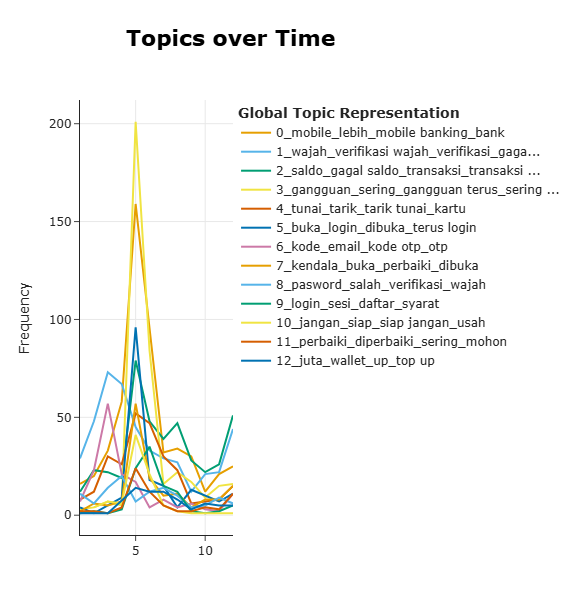

In [16]:
# === Section 8.4: BERTopic native topics_over_time visualization ===

# Plot semua 13 topics (exclude outlier secara default di BERTopic API)
fig_native = topic_model_phase_c.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=13,        # Show all 13 topics
    width=1200,
    height=600,
)
fig_native.show()

In [17]:
# === Section 8.5: Setup matplotlib + topic labels for publication ===
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup output directory
FIG_DIR = Path("outputs/figures/wondr")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Seaborn style untuk publication-grade
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['figure.dpi'] = 100         # display resolution
plt.rcParams['savefig.dpi'] = 300        # SAVE resolution (publication)
plt.rcParams['savefig.bbox'] = 'tight'

# Topic labels — human-readable interpretation dari Phase C
# (sesuai handoff v4 final topic table)
TOPIC_LABELS = {
    0:  "Mobile Banking comparison",
    1:  "Verifikasi wajah gagal",
    2:  "Saldo terpotong / transaksi gagal",
    3:  "Gangguan & maintenance",
    4:  "Tarik tunai tanpa kartu",
    5:  "Aplikasi gak bisa dibuka",
    6:  "OTP / kode verifikasi email",
    7:  "Error 'kendala tim perbaiki'",
    8:  "Password / PIN salah",
    9:  "Sesi berakhir saat login",
    10: "Premature launch complaint",
    11: "Permintaan perbaikan bug",
    12: "Limit top-up wallet",
}

# Quick verify
print(f"FIG_DIR exists: {FIG_DIR.exists()}")
print(f"Number of topic labels: {len(TOPIC_LABELS)}")
print(f"Topics in tot_clean: {sorted(tot_clean['Topic'].unique())}")

FIG_DIR exists: True
Number of topic labels: 13
Topics in tot_clean: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [20]:
print("Sanity check: proportion sum per month (should all = 1.0)")
print(tot_proportion.groupby('Timestamp')['Proportion'].sum())

Sanity check: proportion sum per month (should all = 1.0)
Timestamp
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
Name: Proportion, dtype: float64


In [23]:
# ============================================================
# Section 8.5 (refactored final) — generate official plots
# ============================================================

from utils.visualization import (
    TOPIC_LABELS_WONDR,
    compute_proportion,
    plot_dtm_smallmultiples,
    plot_dtm_proportion,
)

# Generate small multiples (overwrites existing)
sm_path = plot_dtm_smallmultiples(
    tot_clean=tot_clean,
    topic_labels=TOPIC_LABELS_WONDR,
    fig_dir=FIG_DIR,
    app_name="wondr by BNI",
)
print(f"✅ Saved: {sm_path}")

# Generate proportion plot (overwrites existing)
prop_path = plot_dtm_proportion(
    tot_clean=tot_clean,
    topic_labels=TOPIC_LABELS_WONDR,
    fig_dir=FIG_DIR,
    app_name="wondr by BNI",
)
print(f"✅ Saved: {prop_path}")

# Also expose tot_proportion for downstream (Section 8.6 tables)
tot_proportion = compute_proportion(tot_clean)
print(f"✅ tot_proportion ready: {len(tot_proportion)} rows")

✅ Saved: outputs\figures\wondr\08_dtm_smallmultiples.png
✅ Saved: outputs\figures\wondr\08_dtm_proportion.png
✅ tot_proportion ready: 154 rows


## 8.6. Tabel Ringkasan Numerik

Generate 3 CSV reference untuk BAB 4 narrative:
1. **Frequency table** — pivot Topic × Month dengan absolute counts
2. **Proportion table** — pivot Topic × Month dengan normalized proportion
3. **Topic summary** — per-topic peak indicators untuk quick lookup

Saved ke `outputs/tables/`.

In [24]:
# ============================================================
# Section 8.6 — Generate summary tables
# ============================================================

from pathlib import Path

TABLE_DIR = Path("outputs/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Reuse tot_proportion dari Section 8.5 finalize
# Kalau gak ada di kernel, recompute:
# tot_proportion = compute_proportion(tot_clean)

# ------------------------------------------------------------
# Table 1: Frequency pivot (Topic × Month)
# ------------------------------------------------------------
freq_pivot = tot_clean.pivot_table(
    index='Topic',
    columns='Timestamp',
    values='Frequency',
    fill_value=0,
).astype(int)

# Rename columns M1, M2, ... M12
freq_pivot.columns = [f"M{int(c)}" for c in freq_pivot.columns]

# Add Label + Total columns
freq_pivot.insert(0, 'Label', [TOPIC_LABELS_WONDR.get(t, f"Topic {t}") for t in freq_pivot.index])
freq_pivot['Total'] = freq_pivot.iloc[:, 1:].sum(axis=1)  # exclude Label col

freq_path = TABLE_DIR / "wondr_dtm_freq_table.csv"
freq_pivot.to_csv(freq_path, index_label='Topic')
print(f"✅ Table 1 saved: {freq_path}")
print(freq_pivot.head(3))
print()

# ------------------------------------------------------------
# Table 2: Proportion pivot (Topic × Month)
# ------------------------------------------------------------
prop_pivot = tot_proportion.pivot_table(
    index='Topic',
    columns='Timestamp',
    values='Proportion',
    fill_value=0.0,
)
prop_pivot.columns = [f"M{int(c)}" for c in prop_pivot.columns]

# Add Label + Mean columns
prop_pivot.insert(0, 'Label', [TOPIC_LABELS_WONDR.get(t, f"Topic {t}") for t in prop_pivot.index])
prop_pivot['Mean'] = prop_pivot.iloc[:, 1:].mean(axis=1).round(4)

# Round numeric columns to 4 decimals
numeric_cols = [c for c in prop_pivot.columns if c != 'Label']
prop_pivot[numeric_cols] = prop_pivot[numeric_cols].round(4)

prop_path = TABLE_DIR / "wondr_dtm_proportion_table.csv"
prop_pivot.to_csv(prop_path, index_label='Topic')
print(f"✅ Table 2 saved: {prop_path}")
print(prop_pivot.head(3))
print()

# ------------------------------------------------------------
# Table 3: Topic summary (per-topic peak indicators)
# ------------------------------------------------------------
summary_rows = []
for topic_id in sorted(TOPIC_LABELS_WONDR.keys()):
    topic_freq = tot_clean[tot_clean['Topic'] == topic_id]
    topic_prop = tot_proportion[tot_proportion['Topic'] == topic_id]
    
    if len(topic_freq) == 0:
        continue
    
    # Peak by frequency
    peak_freq_row = topic_freq.loc[topic_freq['Frequency'].idxmax()]
    peak_month_freq = int(peak_freq_row['Timestamp'])
    peak_freq_value = int(peak_freq_row['Frequency'])
    
    # Peak by proportion
    peak_prop_row = topic_prop.loc[topic_prop['Proportion'].idxmax()]
    peak_month_prop = int(peak_prop_row['Timestamp'])
    peak_prop_value = round(float(peak_prop_row['Proportion']), 4)
    
    summary_rows.append({
        'Topic': topic_id,
        'Label': TOPIC_LABELS_WONDR[topic_id],
        'Total_N': int(topic_freq['Frequency'].sum()),
        'Peak_Month_Freq': peak_month_freq,
        'Peak_Frequency': peak_freq_value,
        'Peak_Month_Prop': peak_month_prop,
        'Peak_Proportion': peak_prop_value,
        'Mean_Proportion': round(float(topic_prop['Proportion'].mean()), 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = TABLE_DIR / "wondr_topic_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"✅ Table 3 saved: {summary_path}")
print(summary_df)

✅ Table 1 saved: outputs\tables\wondr_dtm_freq_table.csv
                                   Label  M1  M2  M3  M4   M5  M6  M7  M8  M9  \
Topic                                                                           
0              Mobile Banking comparison  16  20  33  58  159  96  32  34  30   
1                 Verifikasi wajah gagal  29  48  73  67   45  33  29  27  12   
2      Saldo terpotong / transaksi gagal  12  23  22  19   79  48  39  47  28   

       M10  M11  M12  Total  
Topic                        
0       12   21   25    536  
1       21   22   44    450  
2       22   26   51    416  

✅ Table 2 saved: outputs\tables\wondr_dtm_proportion_table.csv
                                   Label      M1      M2      M3      M4  \
Topic                                                                      
0              Mobile Banking comparison  0.1667  0.1316  0.1289  0.2367   
1                 Verifikasi wajah gagal  0.3021  0.3158  0.2852  0.2735   
2      Saldo terpot

In [25]:
print(f"Sum of Total in summary: {summary_df['Total_N'].sum()}")
print(f"Sum of Frequency in tot_clean: {tot_clean['Frequency'].sum()}")

Sum of Total in summary: 3024
Sum of Frequency in tot_clean: 3024


In [26]:
print(prop_pivot.iloc[:, 1:-1].sum(axis=0))  # exclude Label & Mean cols

M1     0.9999
M2     1.0001
M3     0.9999
M4     0.9999
M5     0.9999
M6     1.0000
M7     1.0000
M8     1.0000
M9     1.0000
M10    1.0000
M11    1.0002
M12    0.9997
dtype: float64
